In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Niyati\Desktop\olist_cleaned_dataset.csv")

In [6]:
df.head()

,customer_unique_id,num_orders,total_spent,avg_order_value,avg_item_price_per_order,avg_items_per_order,avg_review,avg_installments,city,state,...,cat_pca_1,cat_pca_2,cat_pca_3,cat_pca_4,cat_pca_5,cat_pca_6,cat_pca_7,cat_pca_8,cat_pca_9,cat_pca_10
0,0000366f3b9a7992bf8c76cfdf3221e2,-0.159829,-0.015717,0.003713,0.021035,-0.172165,0.663285,1.898826,cajamar,SP,...,-0.637624,-0.327896,-0.102259,0.059743,-0.020116,0.189493,-0.198020,0.051733,0.008437,0.073418
1,0000b849f77a49e4a4ce2b2a4ca5be3f,-0.159829,-0.574829,-0.570550,-0.561497,-0.172165,-0.120408,-0.707834,osasco,SP,...,-0.209777,0.588827,0.471880,-0.118288,-0.149629,0.046770,-0.092128,0.047734,-0.035847,0.026227
2,0000f46a3911fa3c0805444483337064,-0.159829,-0.322473,-0.311356,-0.298570,-0.172165,-0.904101,1.898826,sao jose,SC,...,-0.018761,-0.047356,-0.095521,0.369686,0.141457,-0.068647,0.166585,0.079676,0.160974,-0.034467
3,0000f6ccb0745a6a4b88665a16c9f078,-0.159829,-0.539117,-0.533870,-0.524289,-0.172165,-0.120408,0.409306,belem,PA,...,0.146240,0.166802,-0.219602,0.525551,-0.100747,-0.413076,-0.126003,0.418943,-0.255063,0.020480
4,0004aac84e0df4da2b147fca70cf8255,-0.159829,0.236639,0.262908,0.283963,-0.172165,0.663285,1.154066,sorocaba,SP,...,0.146240,0.166802,-0.219602,0.525551,-0.100747,-0.413076,-0.126003,0.418943,-0.255063,0.020480


In [9]:
# GMM Clustering (Full Dataset Features)
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# Select numeric features only
numeric_cols = df.select_dtypes(include=['float64','int64']).columns.tolist()

# Remove ID (not numeric anyway)
if 'customer_unique_id' in numeric_cols:
    numeric_cols.remove('customer_unique_id')

X = df[numeric_cols]

# Standardize numeric data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# GMM model
gmm = GaussianMixture(n_components=4, random_state=42)
df['GMM_cluster'] = gmm.fit_predict(X_scaled)
df[['customer_unique_id','GMM_cluster']].head()


,customer_unique_id,GMM_cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [10]:
#STEP 2 — RFM Segmentation
# Create RFM dataframe
rfm = df[['customer_unique_id', 'recency_days', 'num_orders', 'total_spent']]

rfm = rfm.rename(columns={
    'recency_days': 'Recency',
    'num_orders': 'Frequency',
    'total_spent': 'Monetary'
})

# Standardize RFM features
scaler_rfm = StandardScaler()
rfm_scaled = scaler_rfm.fit_transform(rfm[['Recency','Frequency','Monetary']])

# GMM for RFM only
gmm_rfm = GaussianMixture(n_components=4, random_state=42)
rfm['RFM_cluster'] = gmm_rfm.fit_predict(rfm_scaled)

# Add back to main DF
df['RFM_cluster'] = rfm['RFM_cluster']

rfm.head()


,customer_unique_id,Recency,Frequency,Monetary,RFM_cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,-0.790661,-0.159829,-0.015717,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,-0.751176,-0.159829,-0.574829,1
2,0000f46a3911fa3c0805444483337064,1.881163,-0.159829,-0.322473,2
3,0000f6ccb0745a6a4b88665a16c9f078,0.499185,-0.159829,-0.539117,2
4,0004aac84e0df4da2b147fca70cf8255,0.328083,-0.159829,0.236639,2


In [12]:
#STEP 3 — RFM Cluster Summary
rfm_summary = rfm.groupby('RFM_cluster')[['Recency','Frequency','Monetary']].mean()
print(rfm_summary)


              Recency  Frequency  Monetary
RFM_cluster                               
0            0.088784  -0.159829  1.951787
1           -0.706697  -0.159829 -0.229183
2            1.007150  -0.159829 -0.265535
3           -0.119208   5.167323  0.555376


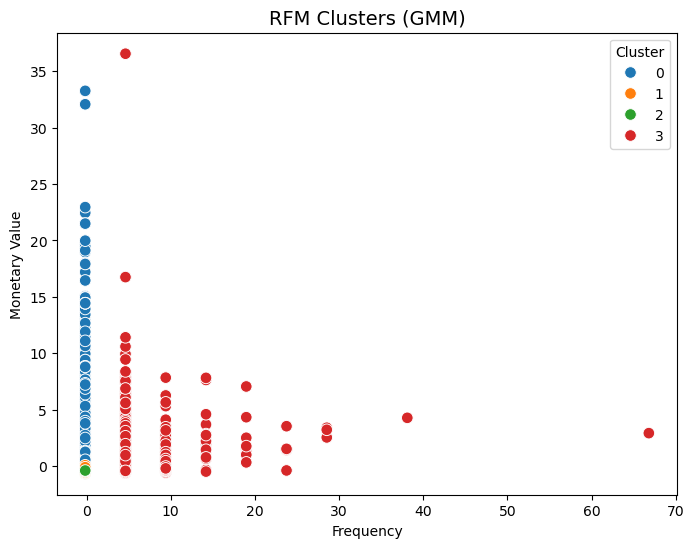

In [13]:
#STEP 4 — Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='RFM_cluster',
    palette='tab10',
    s=70
)
plt.title("RFM Clusters (GMM)", fontsize=14)
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.legend(title='Cluster')
plt.show()


The RFM customer segmentation scatter plot visualizes how customers differ based on their purchasing behavior using Frequency (number of orders) and Monetary Value (total spending). Each color on the graph represents a different customer segment identified through Gaussian Mixture Modeling (GMM). The blue cluster consists of customers who purchase infrequently but spend high amounts when they do, making them “occasional high spenders.” The red cluster contains customers with moderate to very high purchase frequency but generally low monetary value, indicating “frequent low-to-medium spenders.” The orange and green clusters represent small groups of customers who buy rarely and spend very little, capturing “new or one-time buyers” and “low-value casual shoppers.” Overall, the graph reveals clear behavioral patterns and successfully separates customers into meaningful segments based on their RFM characteristics, which can be used for targeted marketing and personalized strategies.

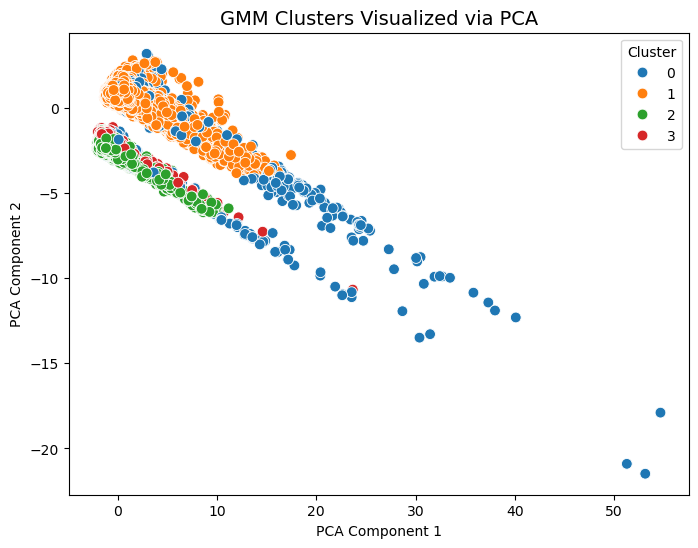

In [16]:
#Plot 2 — GMM Clusters Using PCA (2D)
from sklearn.decomposition import PCA

# PCA to 2 components
pca = PCA(n_components=2)
pca_comp = pca.fit_transform(X_scaled)

df['PCA1'] = pca_comp[:,0]
df['PCA2'] = pca_comp[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['PCA1'],
    y=df['PCA2'],
    hue=df['GMM_cluster'],
    palette='tab10',
    s=60
)
plt.title("GMM Clusters Visualized via PCA", fontsize=14)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.show()


The PCA visualization of GMM customer clusters provides a clear overview of how customers differ based on all numeric behavioral features in the dataset. By reducing the high-dimensional data into two principal components, the plot shows that customers naturally group into four distinct clusters, indicating meaningful behavioral segmentation. Cluster 0 (blue) forms a wide and dispersed group, suggesting high variability in customer behavior and representing customers with diverse purchasing patterns. Cluster 1 (orange) appears more compact and concentrated at the upper-left region of the plot, showing customers with similar and relatively moderate behavior. Cluster 2 (green) is even more tightly packed, suggesting a segment of customers with very consistent and uniform characteristics. Cluster 3 (red) is small and mixed, likely representing unique or outlier customers with less common behavior. Overall, this plot confirms that the GMM model successfully identifies distinct customer groups, and PCA helps visualize how well-separated or overlapping these segments are in the behavioral feature space.